# Random Forest Benchmark for Irrigation Classification

In [1]:
# %% Imports
import os
import glob
import numpy as np
import rasterio
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    accuracy_score, jaccard_score, f1_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib
import json

In [3]:
# %% Configuration
base_dir = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction-openet/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/'
TRAIN_DIR = os.path.join(base_dir,'training_chips')
VAL_DIR = os.path.join(base_dir,'validation_chips')
OUTPUT_DIR = 'rf_outputs'

CLASS_NAMES = ["Water", "non-ag", "Irrigated", "Rainfed"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(42)

In [4]:
# %% Find training chips
train_images = sorted(glob.glob(os.path.join(TRAIN_DIR, '*_merged.tif')))
print(f"Found {len(train_images)} training chips")
print(f"Example: {train_images[0]}")

# %% Load ONE chip to check structure
test_img_path = train_images[0]
test_mask_path = test_img_path.replace('_merged.tif', '.mask.tif')

with rasterio.open(test_img_path) as src:
    test_img = src.read()
    print(f"Image shape: {test_img.shape}")  # Should be (18, H, W)
    print(f"Image dtype: {test_img.dtype}")

with rasterio.open(test_mask_path) as src:
    test_mask = src.read(1)
    print(f"Mask shape: {test_mask.shape}")  # Should be (H, W)
    print(f"Unique mask values: {np.unique(test_mask)}")

Found 2013 training chips
Example: /discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction-openet/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/chip_003_062_merged.tif
Image shape: (18, 224, 224)
Image dtype: int16
Mask shape: (224, 224)
Unique mask values: [0 1 2 3]


In [5]:
# %% Load all TRAINING chips
all_X_train = []
all_y_train = []

for img_path in tqdm(train_images, desc="Loading training"):
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    
    if not os.path.exists(mask_path):
        print(f"No mask for {img_path}")
        continue
    
    # Read
    with rasterio.open(img_path) as src:
        img = src.read()  # (18, H, W)
    with rasterio.open(mask_path) as src:
        mask = src.read(1)  # (H, W)
    
    # Reshape to pixels: (18, H, W) -> (H*W, 18)
    n_bands, H, W = img.shape
    X = img.reshape(n_bands, -1).T  # (H*W, 18)
    y = mask.flatten()  # (H*W,)
    
    # Keep valid pixels only (classes 0-3)
    valid = (y >= 0) & (y < 4)
    X = X[valid]
    y = y[valid]
    
    all_X_train.append(X)
    all_y_train.append(y)

X_train = np.concatenate(all_X_train)
y_train = np.concatenate(all_y_train)

print(f"\nTraining data: {X_train.shape[0]:,} pixels, {X_train.shape[1]} features")

Loading training: 100%|██████████| 2013/2013 [01:31<00:00, 22.11it/s]



Training data: 100,392,596 pixels, 18 features


In [6]:
# %% Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Training class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  {CLASS_NAMES[int(cls)]}: {cnt:,} ({100*cnt/len(y_train):.1f}%)")

Training class distribution:
  Water: 3,399,382 (3.4%)
  non-ag: 47,201,984 (47.0%)
  Irrigated: 31,563,596 (31.4%)
  Rainfed: 18,227,634 (18.2%)


In [7]:
# %% Load all VALIDATION chips
val_images = sorted(glob.glob(os.path.join(VAL_DIR, '*_merged.tif')))
print(f"Found {len(val_images)} validation chips")

all_X_val = []
all_y_val = []

for img_path in tqdm(val_images, desc="Loading validation"):
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    
    if not os.path.exists(mask_path):
        continue
    
    with rasterio.open(img_path) as src:
        img = src.read()
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    n_bands, H, W = img.shape
    X = img.reshape(n_bands, -1).T
    y = mask.flatten()
    
    valid = (y >= 0) & (y < 4)
    X = X[valid]
    y = y[valid]
    
    all_X_val.append(X)
    all_y_val.append(y)

X_val = np.concatenate(all_X_val)
y_val = np.concatenate(all_y_val)

print(f"\nValidation data: {X_val.shape[0]:,} pixels")

Found 486 validation chips


Loading validation: 100%|██████████| 486/486 [00:20<00:00, 24.26it/s]


Validation data: 24,217,363 pixels


In [14]:
# %% (Optional) Subsample training data if too large
MAX_TRAIN_PIXELS = 80_000_000

if len(y_train) > MAX_TRAIN_PIXELS:
    print(f"Subsampling: {len(y_train):,} -> {MAX_TRAIN_PIXELS:,}")
    idx = np.random.choice(len(y_train), MAX_TRAIN_PIXELS, replace=False)
    X_train = X_train[idx]
    y_train = y_train[idx]

# %% Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Training...")
rf.fit(X_train, y_train)
print("Done!")

Training...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 46 concurrent workers.
[Parallel(n_jobs=-1)]: Done 108 tasks      | elapsed:  1.5min


Done!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.4min finished


Predicting...


/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed

RESULTS
Accuracy:     0.7329
Mean Jaccard: 0.5406
Mean F1:      0.6966

Per-class Jaccard (IoU):
  Water: 0.5011
  non-ag: 0.6816
  Irrigated: 0.5657
  Rainfed: 0.4140

              precision    recall  f1-score   support

       Water     0.5874    0.7734    0.6677    895744
      non-ag     0.8377    0.7854    0.8107  11471267
   Irrigated     0.7467    0.7000    0.7226   7385350
     Rainfed     0.5367    0.6443    0.5856   4465002

    accuracy                         0.7329  24217363
   macro avg     0.6771    0.7257    0.6966  24217363
weighted avg     0.7452    0.7329    0.7370  24217363



<Figure size 800x600 with 0 Axes>

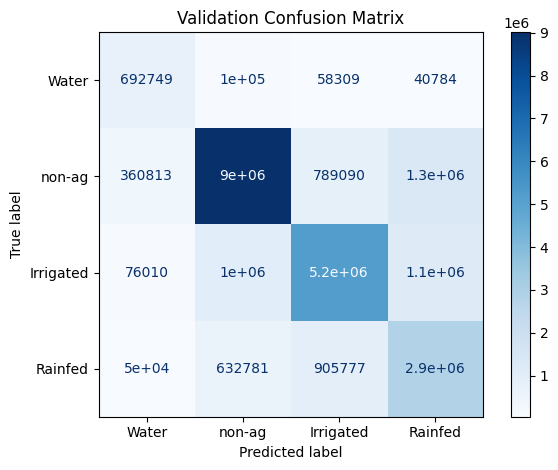

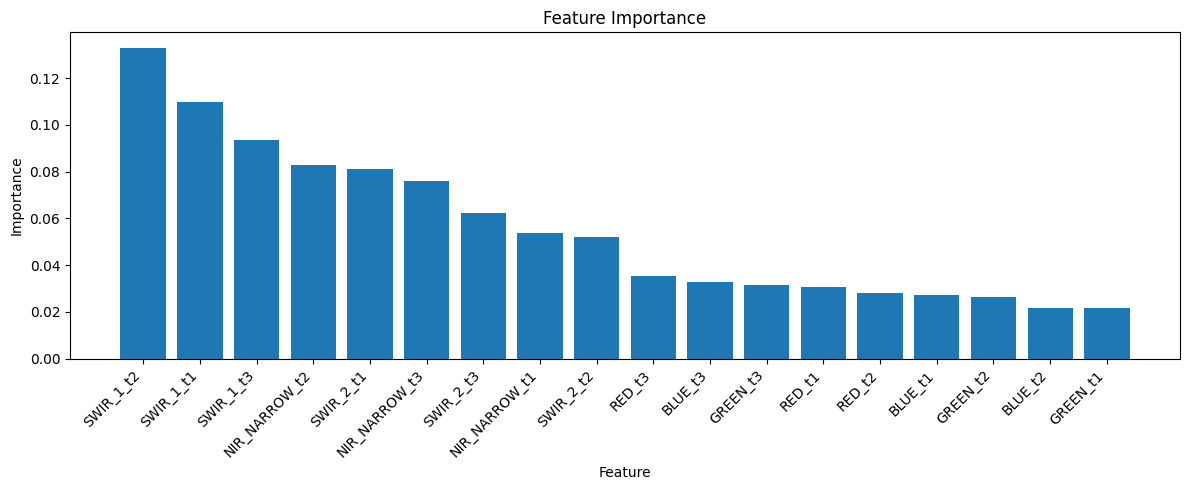


Saved to rf_outputs/


In [9]:
# %% Predict on validation
print("Predicting...")
rf = joblib.load('./rf_outputs/rf_model.joblib')

y_pred = rf.predict(X_val)

# %% Calculate metrics
acc = accuracy_score(y_val, y_pred)
jaccard = jaccard_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

print("=" * 50)
print("RESULTS")
print("=" * 50)
print(f"Accuracy:     {acc:.4f}")
print(f"Mean Jaccard: {jaccard:.4f}")
print(f"Mean F1:      {f1:.4f}")

# %% Per-class Jaccard
per_class_jaccard = jaccard_score(y_val, y_pred, average=None)

print("\nPer-class Jaccard (IoU):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {per_class_jaccard[i]:.4f}")

# %% Classification report
print("\n" + classification_report(y_val, y_pred, target_names=CLASS_NAMES, digits=4))

# %% Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()

# %% Feature importance
band_names = ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"]
feature_names = [f"{b}_t{t+1}" for t in range(3) for b in band_names]

importance = rf.feature_importances_

plt.figure(figsize=(12, 5))
sorted_idx = np.argsort(importance)[::-1]
plt.bar(range(len(importance)), importance[sorted_idx])
plt.xticks(range(len(importance)), [feature_names[i] for i in sorted_idx], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=300)
plt.show()

# %% Save model and results
joblib.dump(rf, os.path.join(OUTPUT_DIR, 'rf_model.joblib'))

results = {
    'accuracy': float(acc),
    'mean_jaccard': float(jaccard),
    'mean_f1': float(f1),
    'per_class_jaccard': {CLASS_NAMES[i]: float(per_class_jaccard[i]) for i in range(4)},
    'train_pixels': int(len(y_train)),
    'val_pixels': int(len(y_val)),
}

with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nSaved to {OUTPUT_DIR}/")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Do

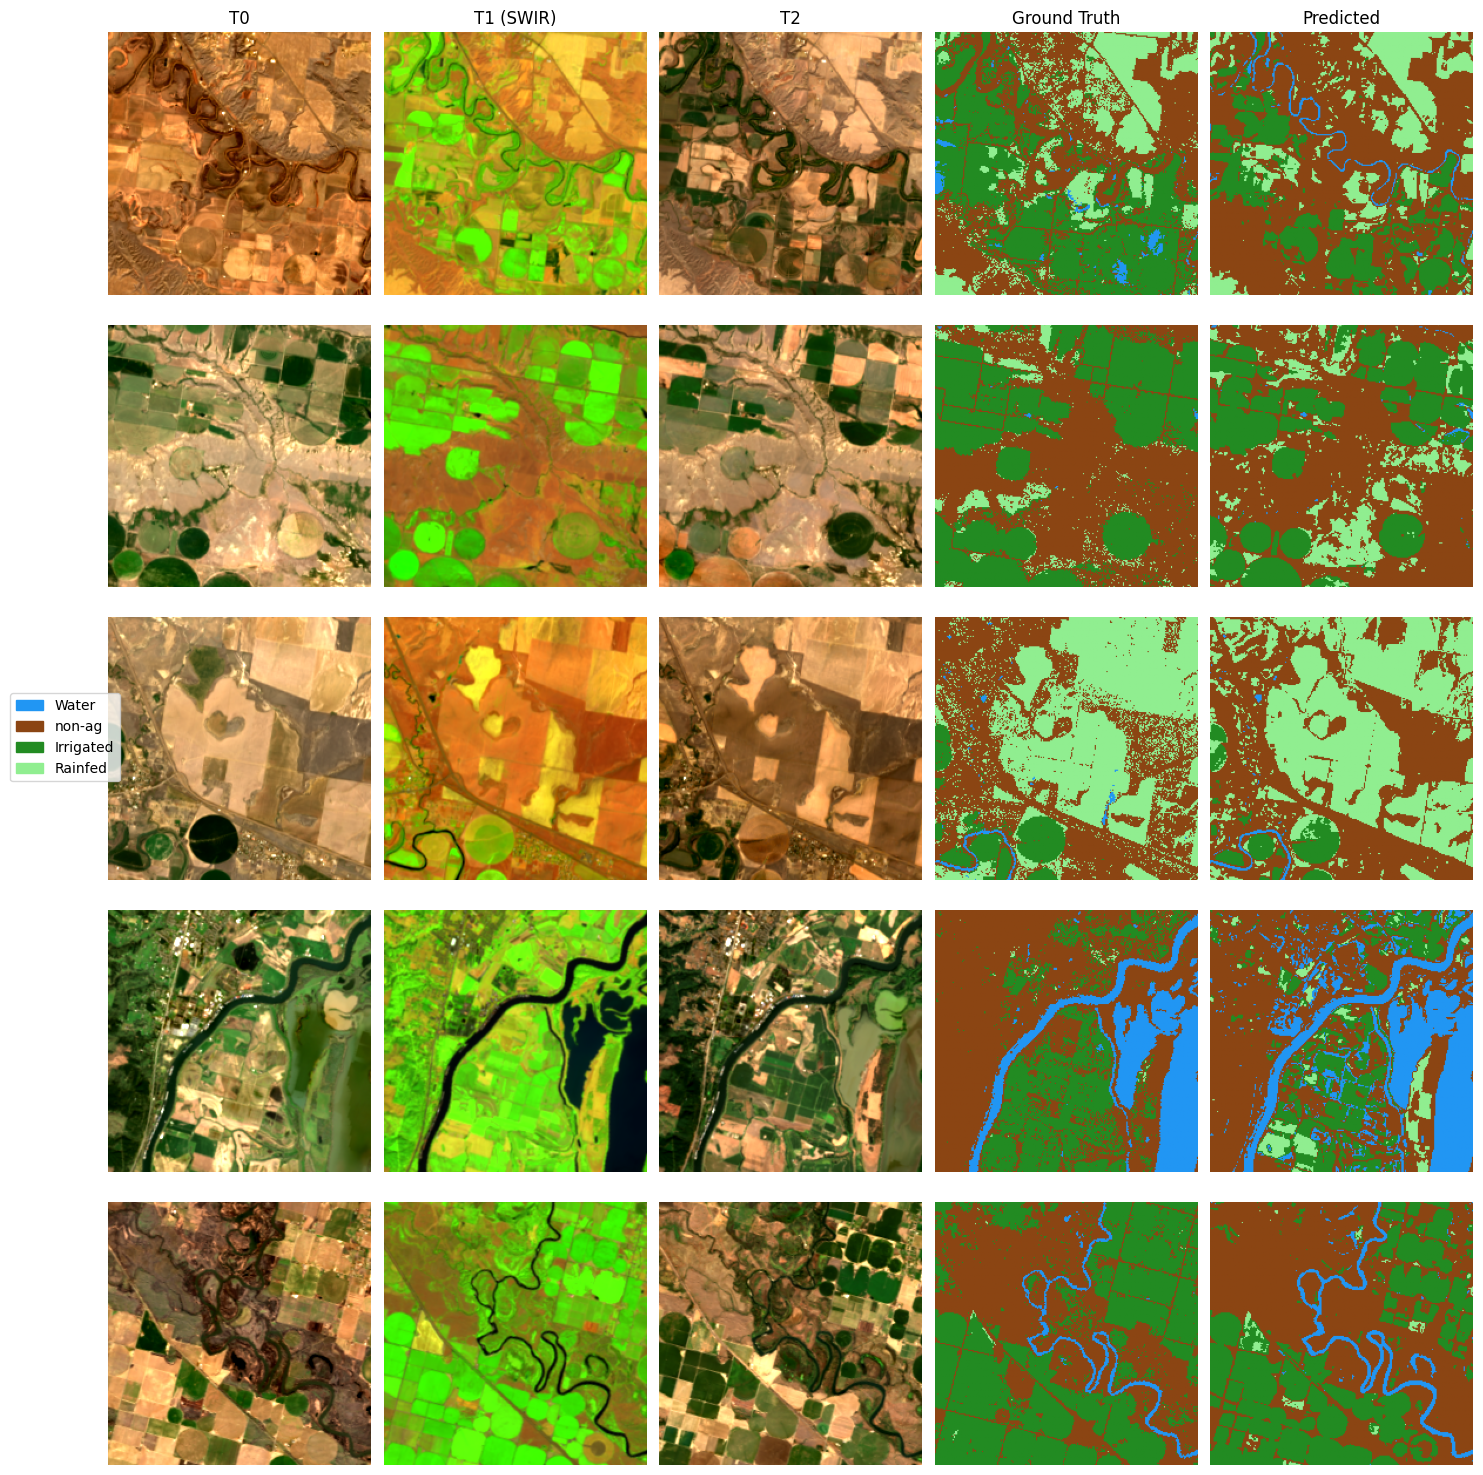

In [10]:
# %% Visualize predictions for sample chips
import matplotlib.patches as mpatches

n_chips = 5
np.random.seed(42)
# sample_indices = np.random.choice(len(val_images), n_chips, replace=False)
sample_indices = range(10,15)
fig, axes = plt.subplots(n_chips, 5, figsize=(15, 3*n_chips))

colors = ['#2196F3', '#8B4513', '#228B22', '#90EE90']
cmap = plt.cm.colors.ListedColormap(colors)

def norm(arr):
    p2, p98 = np.percentile(arr, (2, 98))
    return np.clip((arr - p2) / (p98 - p2 + 1e-6), 0, 1)

for row, idx in enumerate(sample_indices):
    img_path = val_images[idx]
    mask_path = img_path.replace('_merged.tif', '.mask.tif')
    
    with rasterio.open(img_path) as src:
        img = src.read()
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    
    H, W = mask.shape
    
    t0 = norm(np.moveaxis(img[2::-1], 0, -1))              # RGB
    t1 = norm(np.moveaxis(img[[10, 9, 6]], 0, -1))         # SWIR1, NIR, GREEN
    t2 = norm(np.moveaxis(img[14:11:-1], 0, -1))           # RGB
    
    X = img.reshape(18, -1).T
    pred = rf.predict(X).reshape(H, W)
    
    axes[row, 0].imshow(t0)
    axes[row, 1].imshow(t1)
    axes[row, 2].imshow(t2)
    axes[row, 3].imshow(mask, cmap=cmap, vmin=0, vmax=3)
    axes[row, 4].imshow(pred, cmap=cmap, vmin=0, vmax=3)
    
    for ax in axes[row]:
        ax.axis('off')

axes[0, 0].set_title('T0')
axes[0, 1].set_title('T1 (SWIR)')
axes[0, 2].set_title('T2')
axes[0, 3].set_title('Ground Truth')
axes[0, 4].set_title('Predicted')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, CLASS_NAMES)]
fig.legend(handles=patches, loc='center left', bbox_to_anchor=(0.01, 0.5))

plt.tight_layout()
plt.subplots_adjust(left=0.08)
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_samples.png'), dpi=300, bbox_inches='tight')
plt.show()